In [1]:
file_refit_read = "006_refit_noise"
file_rmse_read = "007_RMSE_noise"
file_write = "008_coefs_noise"

In [2]:
import polars as pl

df_rmse = pl.read_parquet(f"{file_rmse_read}_summary.parquet")

In [3]:
df_rmse

noise_ratio,n_features,beta_av_rmse
f64,i32,f64
0.0,11,3.861018
0.1,11,3.884787
0.2,11,4.14617
0.3,10,4.617747
0.4,10,5.195546
…,…,…
0.6,11,6.600627
0.7,23,7.514426
0.8,21,8.249834


In [4]:
import numpy as np

df_coefs_min = []

for ratio in np.arange(0, 1.1, 0.1):
    
    if ratio == 0.0:
        df_coefs = pl.read_parquet("001_refit_coefs.parquet")
        n_features_min = 11
    else:
        df_coefs = pl.read_parquet(f"{file_refit_read}_coefs_{ratio:.1f}.parquet")
        n_features_min = df_rmse.filter(pl.col("noise_ratio") == ratio)["n_features"][0]
        
    df_coefs_min.append(df_coefs.filter(pl.col("n_features") == n_features_min))    

In [5]:
df_coefs_min = pl.concat(df_coefs_min, how="diagonal_relaxed")

In [6]:
df_coefs_min

n_features,alpha,2_zero,3_zero,4_zero,6_zero,7_zero,9_zero,12_zero,14_zero,16_zero,18_zero,19_zero,21_zero,46_zero,68_zero,91_zero,148_zero,157_zero,161_zero,232_zero,234_zero,235_zero,237_zero,240_zero,247_zero,252_zero,255_zero,270_zero,271_zero,275_zero,293_zero,324_zero,327_zero,355_zero,357_zero,415_zero,442_zero,465_zero,469_zero,494_zero,505_zero,506_zero,507_zero,519_zero,538_zero,540_zero,543_zero,575_zero,597_zero,602_zero,605_zero,642_zero
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
11,0.2,null,null,null,null,0.498711,null,null,null,null,null,null,null,null,null,-0.448177,null,null,null,-0.327649,0.355742,0.610951,null,-0.900349,null,null,null,null,0.829352,null,null,-0.890746,null,null,null,null,null,null,-0.355727,0.235519,null,null,null,null,null,null,0.502156,null,null,null,null,null
11,0.17,null,null,null,null,0.459389,null,null,null,null,null,null,null,null,null,-0.496148,null,null,null,-0.358763,0.392358,0.648912,null,-0.922069,null,null,null,null,0.809679,null,null,-0.891985,null,null,null,null,null,null,-0.275085,0.297126,null,null,null,null,null,null,0.482366,null,null,null,null,null
11,0.15,null,null,null,null,0.415972,null,null,null,null,null,null,null,null,null,-0.53999,null,null,null,-0.388186,0.426673,0.68056,null,-0.931345,null,null,null,null,0.77892,null,null,-0.886678,null,null,null,null,null,null,-0.19164,0.357886,null,null,null,null,null,null,0.457682,null,null,null,null,null
10,0.01,null,null,null,null,0.338314,null,null,null,null,null,null,null,null,null,-0.658749,null,null,null,-0.417592,0.491593,0.793777,null,-1.003347,null,null,null,null,0.731644,null,null,-0.921056,null,null,null,null,null,null,null,0.438183,null,null,null,null,null,null,0.455119,null,null,null,null,null
10,0.05,null,null,null,null,0.312984,null,null,null,null,null,null,null,null,null,-0.635427,null,null,null,-0.435456,0.490126,0.751205,null,-0.956723,null,null,null,null,0.710456,null,null,-0.863369,null,null,null,null,null,null,null,0.472895,null,null,null,null,null,null,0.406062,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11,0.74,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.519904,null,null,null,-0.453575,0.584869,0.553174,null,-0.686969,null,null,null,null,0.631498,null,null,-0.653744,null,null,null,null,null,0.518856,null,0.493522,null,-0.526254,null,null,null,null,0.317464,null,null,null,null,null
23,5.25,-0.11376,null,null,null,0.218065,-0.126668,null,null,null,null,0.199355,null,null,null,-0.179572,null,-0.17637,null,-0.411242,0.29179,0.241291,null,-0.184412,0.081912,null,null,null,0.141573,0.116694,null,-0.182327,null,null,null,null,null,0.182408,null,0.235553,null,-0.182462,0.092625,null,null,null,0.226722,-0.161624,-0.273642,-0.093835,-0.093667,null
21,4.89,-0.129999,null,null,null,0.230433,-0.121436,null,null,null,null,0.189615,null,null,null,-0.189456,null,-0.151037,null,-0.410464,0.291551,0.254579,null,-0.206532,0.085439,null,null,null,0.104374,0.143021,null,-0.182112,null,null,null,null,null,0.232189,null,0.253944,null,-0.183312,null,null,null,null,0.223601,-0.180594,-0.303392,-0.102154,null,null


In [7]:
columns_feat = [column for column in df_coefs_min.columns if "zero" in column]

In [8]:
data = df_coefs_min[columns_feat].to_numpy()

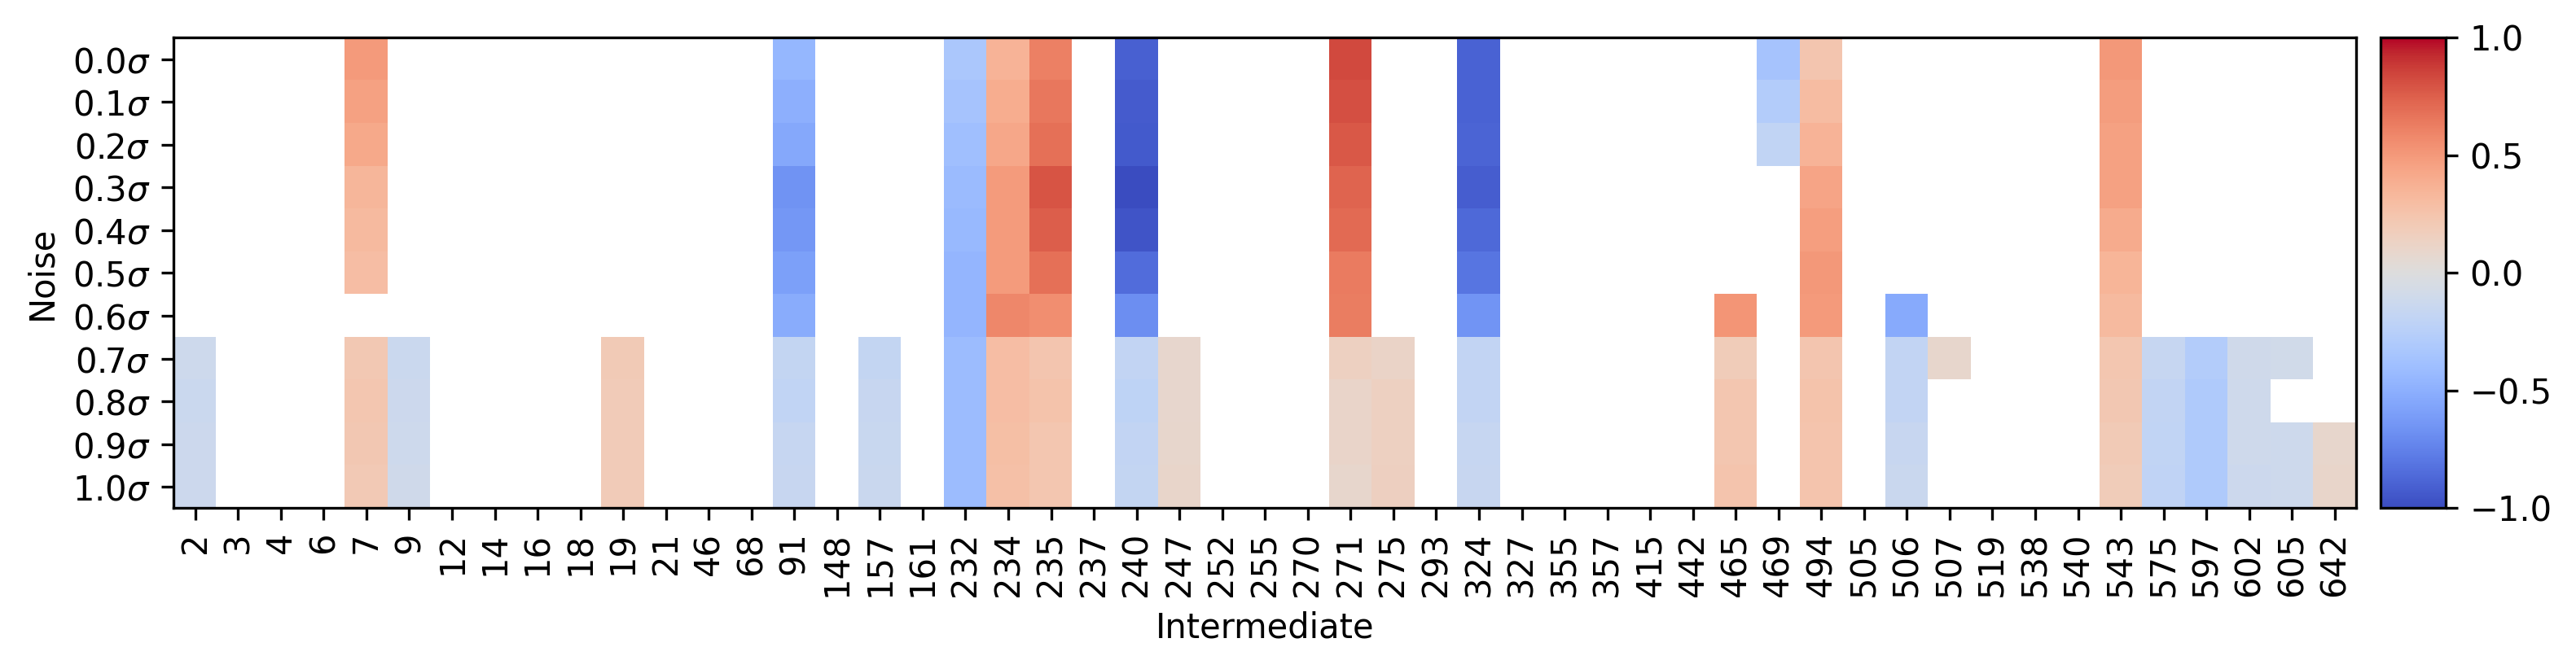

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 4), dpi=300)

im = ax.imshow(data, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xlabel("Intermediate")
ax.set_ylabel("Noise")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.set_yticklabels([f"{i/10}$\sigma$" for i in range(11)])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file_write}_imshow.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()